# SARIMAX ile Su Talebi Tahmini

Bu notebook, Malatya gunluk su tuketimi verisi icin SARIMAX modeli kurar, test eder ve kaydeder.

## 1) Kutuphaneler

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels>=0.14.0'])
    from statsmodels.tsa.statespace.sarimax import SARIMAX

np.random.seed(42)
print('Kutuphaneler hazir.')

Kutuphaneler hazir.


## 2) Veri Yukleme

In [2]:
df_su = pd.read_csv('malatya_gunluk_su_tuketimi_20yil.csv')
df_yagis = pd.read_csv('malatya_gunluk_yagis_20yil.csv')

print('Su veri boyutu   :', df_su.shape)
print('Yagis veri boyutu:', df_yagis.shape)
print('Su sutunlari     :', list(df_su.columns))
print('Yagis sutunlari  :', list(df_yagis.columns))

Su veri boyutu   : (7305, 4)
Yagis veri boyutu: (7305, 5)
Su sutunlari     : ['Tarih', 'Ort_Sicaklik', 'Hafta_Sonu', 'Su_Tuketimi_m3']
Yagis sutunlari  : ['Tarih', 'Karakaya_Yagis_mm', 'Surgu_Yagis_mm', 'Sultansuyu_Yagis_mm', 'Genel_Ortalama_mm']


## 3) Veri Hazirlama ve Ozellikler

In [3]:
df_su = df_su.copy()
df_yagis = df_yagis.copy()

df_su['date'] = pd.to_datetime(df_su['Tarih'], errors='coerce')
df_yagis['date'] = pd.to_datetime(df_yagis['Tarih'], errors='coerce')

df = pd.merge(
    df_su[['date', 'Su_Tuketimi_m3', 'Ort_Sicaklik', 'Hafta_Sonu']],
    df_yagis[['date', 'Genel_Ortalama_mm']],
    on='date',
    how='inner'
)

df = df.sort_values('date').dropna().reset_index(drop=True)
df = df.rename(columns={
    'Su_Tuketimi_m3': 'y',
    'Ort_Sicaklik': 'sicaklik',
    'Hafta_Sonu': 'hafta_sonu',
    'Genel_Ortalama_mm': 'yagis_mm'
})

df['hafta_sonu'] = df['hafta_sonu'].astype(int)

print('Model veri boyutu:', df.shape)
df.head()

Model veri boyutu: (7305, 5)


,date,y,sicaklik,hafta_sonu,yagis_mm
0,2004-01-01,93910,-1.7,0,0.0
1,2004-01-02,96421,-1.2,0,0.0
2,2004-01-03,102581,-5.7,1,0.0
3,2004-01-04,103912,0.9,1,0.0
4,2004-01-05,95013,-3.6,0,1.0


## 4) Kesif Grafikleri

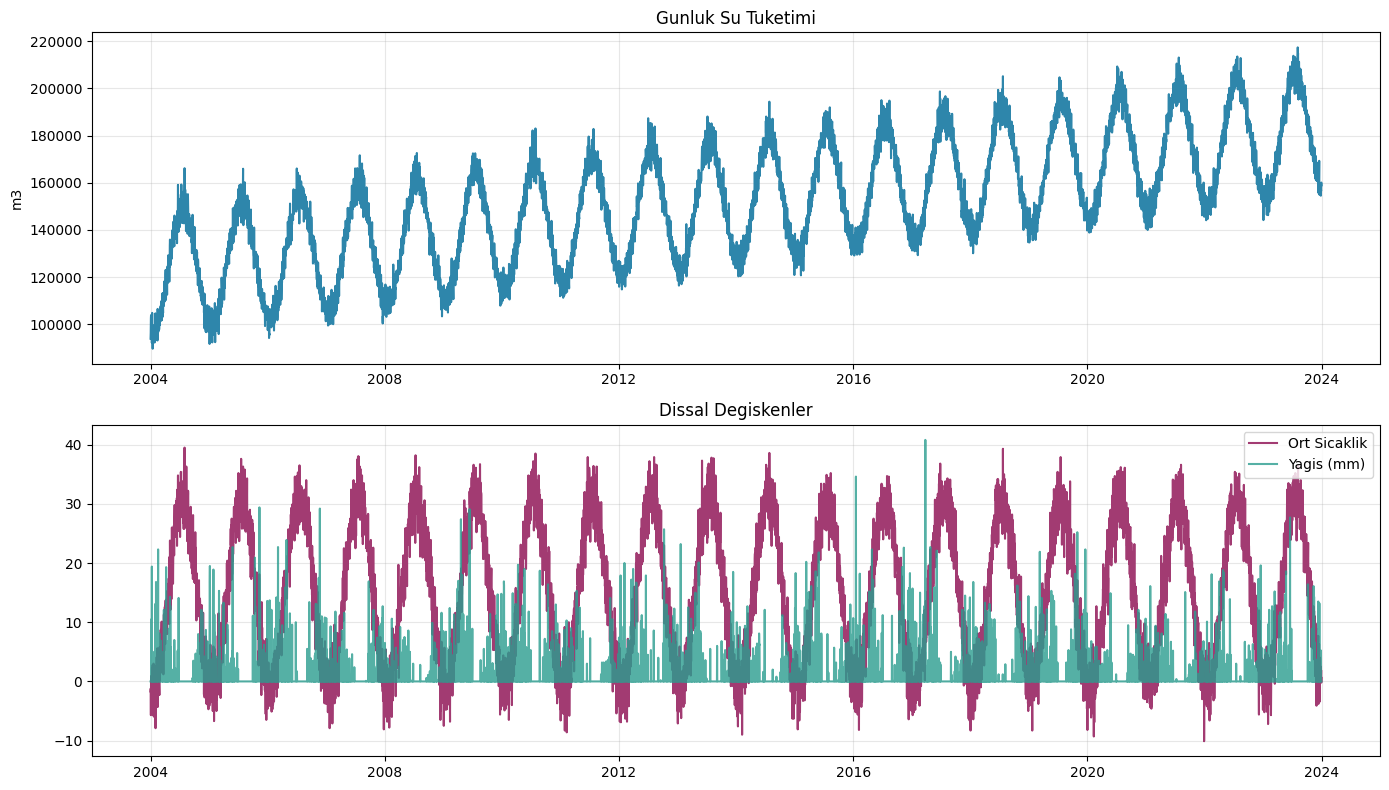

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['date'], df['y'], color='#2E86AB')
axes[0].set_title('Gunluk Su Tuketimi')
axes[0].set_ylabel('m3')
axes[0].grid(alpha=0.3)

axes[1].plot(df['date'], df['sicaklik'], label='Ort Sicaklik', color='#A23B72')
axes[1].plot(df['date'], df['yagis_mm'], label='Yagis (mm)', color='#2A9D8F', alpha=0.8)
axes[1].set_title('Dissal Degiskenler')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5) Train/Test Ayrimi

In [5]:
target = df['y']
exog = df[['sicaklik', 'hafta_sonu', 'yagis_mm']]

split_idx = int(len(df) * 0.8)

y_train = target.iloc[:split_idx]
y_test = target.iloc[split_idx:]
X_train = exog.iloc[:split_idx]
X_test = exog.iloc[split_idx:]

date_train = df['date'].iloc[:split_idx]
date_test = df['date'].iloc[split_idx:]

print('Train boyutu:', y_train.shape[0])
print('Test boyutu :', y_test.shape[0])

Train boyutu: 5844
Test boyutu : 1461


## 6) SARIMAX Model Kurulumu ve Egitim

In [6]:
# Haftalik sezonsallik: m=7
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 7)

model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 5844
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -56260.976
Date:                           Thu, 16 Apr 2026   AIC                         112537.951
Time:                                   13:28:09   BIC                         112591.314
Sample:                                        0   HQIC                        112556.510
                                          - 5844                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sicaklik     357.1415     14.818     24.103      0.000     328.100     386.183
hafta_sonu    -0.0611   2387.239  -2.56e-05

## 7) Test Tahmini ve Metrikler

In [11]:
# Rolling one-step forecast: her adimda gercek deger modele eklenir
rolling_results = results
preds = []
lower_list = []
upper_list = []

for i in range(len(y_test)):
    idx_i = y_test.index[i]
    exog_i = X_test.loc[[idx_i]]
    fc = rolling_results.get_forecast(steps=1, exog=exog_i)

    pred_i = float(fc.predicted_mean.iloc[0])
    ci_i = fc.conf_int(alpha=0.05).iloc[0]

    preds.append(pred_i)
    lower_list.append(float(ci_i.iloc[0]))
    upper_list.append(float(ci_i.iloc[1]))

    # Gercek degeri modele ekle (refit yok, hizli guncelleme)
    endog_i = pd.Series([y_test.loc[idx_i]], index=[idx_i], name=y_train.name)
    rolling_results = rolling_results.append(
        endog=endog_i,
        exog=exog_i,
        refit=False
    )

y_pred = pd.Series(preds, index=y_test.index)

# Sonraki hucrelerde de kullanilsin
final_results = rolling_results

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print('=== SARIMAX TEST SONUCLARI (ROLLING 1-STEP) ===')
print(f'MAE : {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R2  : {r2:.4f}')
print(f'MAPE: {mape:.2%}')

=== SARIMAX TEST SONUCLARI (ROLLING 1-STEP) ===
MAE : 2,853.93
RMSE: 3,592.04
R2  : 0.9652
MAPE: 1.64%


## 8) Tahmin Grafik

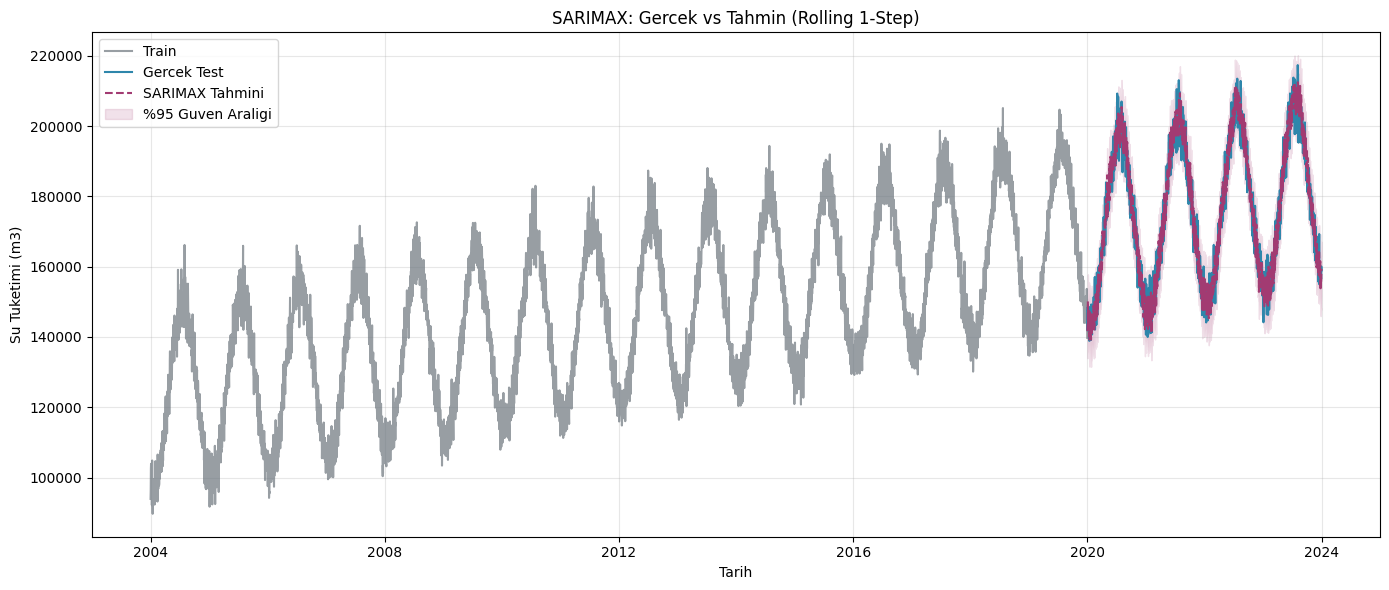

In [12]:
lower = pd.Series(lower_list, index=y_test.index)
upper = pd.Series(upper_list, index=y_test.index)

plt.figure(figsize=(14, 6))
plt.plot(date_train, y_train, label='Train', color='#6c757d', alpha=0.7)
plt.plot(date_test, y_test, label='Gercek Test', color='#2E86AB')
plt.plot(date_test, y_pred, label='SARIMAX Tahmini', color='#A23B72', linestyle='--')
plt.fill_between(date_test, lower, upper, color='#A23B72', alpha=0.15, label='%95 Guven Araligi')
plt.title('SARIMAX: Gercek vs Tahmin (Rolling 1-Step)')
plt.xlabel('Tarih')
plt.ylabel('Su Tuketimi (m3)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9) Artik (Residual) Analizi

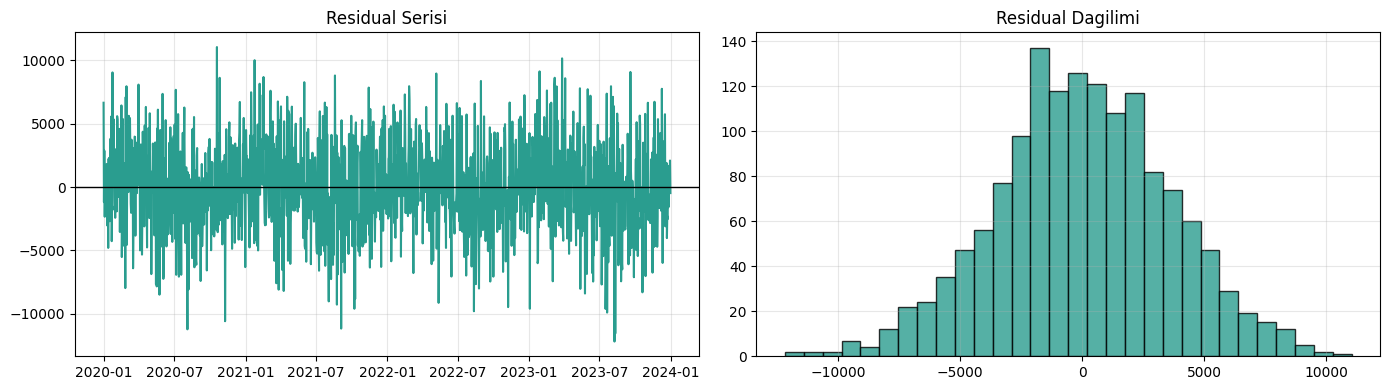

Residual ortalama: -4.838032140666219
Residual std     : 3592.035217456693


In [13]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(date_test, residuals, color='#2A9D8F')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residual Serisi')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=30, color='#2A9D8F', edgecolor='black', alpha=0.8)
axes[1].set_title('Residual Dagilimi')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Residual ortalama:', float(np.mean(residuals)))
print('Residual std     :', float(np.std(residuals)))

## 10) Gelecek 30 Gun Tahmini

In [14]:
future_steps = 30

# Gelecek exog icin son 30 gunu tekrar kullan
recent_exog = exog.iloc[-future_steps:].copy().reset_index(drop=True)
future_exog = recent_exog.copy()

# Test sonuna kadar guncellenmis modeli kullan
future_forecast = final_results.get_forecast(steps=future_steps, exog=future_exog).predicted_mean

last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='D')

future_df = pd.DataFrame({
    'date': future_dates,
    'sarimax_tahmin_m3': future_forecast.values
})

future_df.head()

,date,sarimax_tahmin_m3
0,2024-01-01,155239.508913
1,2024-01-02,155919.647737
2,2024-01-03,154277.808419
3,2024-01-04,154657.209982
4,2024-01-05,155865.019647


## 11) Gelecek Tahmin Grafigi

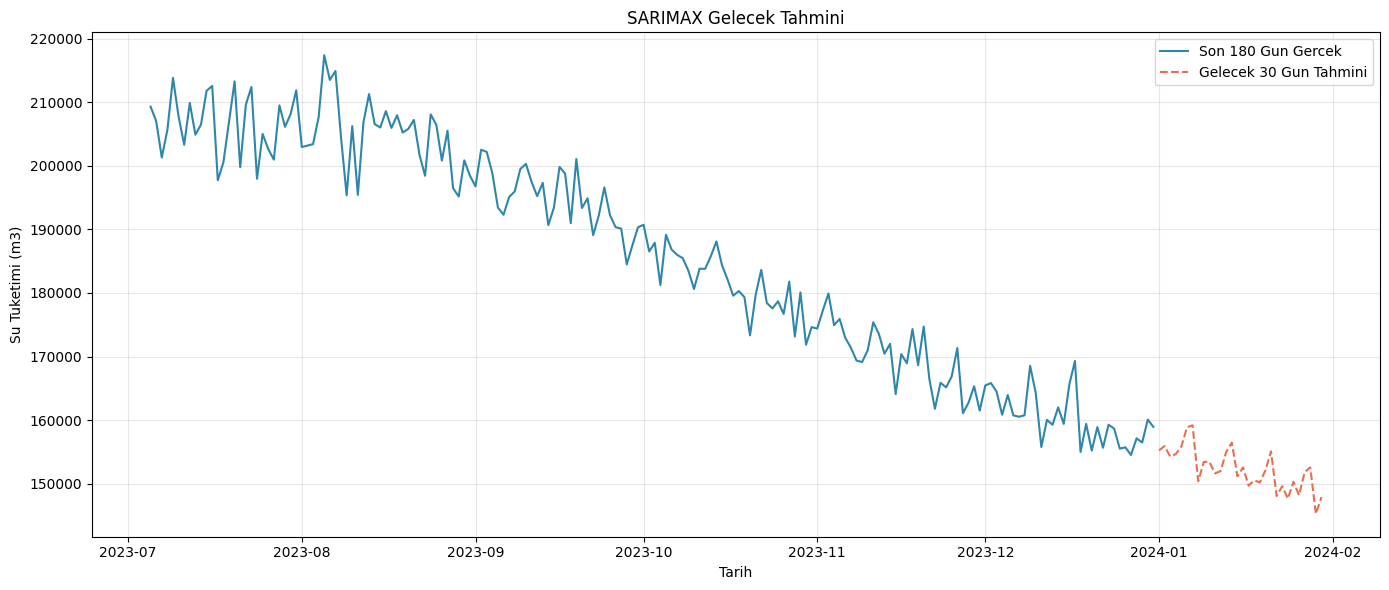

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'].tail(180), df['y'].tail(180), label='Son 180 Gun Gercek', color='#2E86AB')
plt.plot(future_df['date'], future_df['sarimax_tahmin_m3'], label='Gelecek 30 Gun Tahmini', color='#E76F51', linestyle='--')
plt.title('SARIMAX Gelecek Tahmini')
plt.xlabel('Tarih')
plt.ylabel('Su Tuketimi (m3)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12) Modeli Kaydet

In [16]:
results.save('sarimax_su_tahmin_modeli.pkl')

joblib.dump({
    'order': order,
    'seasonal_order': seasonal_order,
    'features': ['sicaklik', 'hafta_sonu', 'yagis_mm'],
    'target': 'y',
    'metrics': {
        'MAE': float(mae),
        'RMSE': float(rmse),
        'R2': float(r2),
        'MAPE': float(mape)
    }
}, 'sarimax_model_info.joblib')

future_df.to_csv('sarimax_gelecek_30gun_tahmin.csv', index=False)

print('Kaydedildi: sarimax_su_tahmin_modeli.pkl')
print('Kaydedildi: sarimax_model_info.joblib')
print('Kaydedildi: sarimax_gelecek_30gun_tahmin.csv')

Kaydedildi: sarimax_su_tahmin_modeli.pkl
Kaydedildi: sarimax_model_info.joblib
Kaydedildi: sarimax_gelecek_30gun_tahmin.csv
